# Synthetic Weather Data Analysis

This notebook generates and analyzes synthetic weather station data.

The goal is to practice Python, NumPy, pandas and matplotlib using a realistic sensor-data workflow.

## Objectives

1. Generate synthetic weather data.
2. Save the dataset as a CSV file.
3. Load the dataset with pandas.
4. Visualize temperature, humidity, pressure and light.
5. Calculate basic statistics.
6. Write simple conclusions.


## 1. Import libraries

We start by importing the main Python libraries for scientific data analysis.

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Define project paths

We define the path where the synthetic dataset will be saved.

In [6]:
DATA_RAW_PATH = Path("../data/raw")
OUTPUT_FILE = DATA_RAW_PATH / "synthetic_weather_data.csv"

DATA_RAW_PATH.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE

WindowsPath('../data/raw/synthetic_weather_data.csv')

In [7]:
num_samples = 24 * 7  # 7 days of hourly data

timestamps = pd.date_range(
    start="2026-01-01 00:00:00",
    periods=num_samples,
    freq="h"
)

timestamps[:5]

DatetimeIndex(['2026-01-01 00:00:00', '2026-01-01 01:00:00',
               '2026-01-01 02:00:00', '2026-01-01 03:00:00',
               '2026-01-01 04:00:00'],
              dtype='datetime64[us]', freq='h')

## 4. Generate synthetic temperature data

Temperature is simulated using a daily cycle plus random noise.

In [10]:
np.random.seed(42)

hours = np.arange(num_samples)

temperature = 18 + 6 * np.sin(2 * np.pi * hours / 24) + np.random.normal(0, 1.0, num_samples)

temperature[:10]

array([18.49671415, 19.41464997, 21.64768854, 23.76567054, 22.96199905,
       23.561418  , 25.57921282, 24.56298969, 22.72667804, 22.78520073])

## 5. Generate humidity, pressure and light data

We add more synthetic sensor variables to make the dataset more realistic.

In [11]:
humidity = 65 - 10 * np.sin(2 * np.pi * hours / 24) + np.random.normal(0, 4.0, num_samples)

pressure = 1013 + 3 * np.sin(2 * np.pi * hours / (24 * 3)) + np.random.normal(0, 1.5, num_samples)

light = np.maximum(
    0,
    800 * np.sin(2 * np.pi * (hours - 6) / 24)
) + np.random.normal(0, 30, num_samples)

light = np.clip(light, 0, None)

## 6. Create a pandas DataFrame

We combine all generated variables into a structured dataset.

In [12]:
df = pd.DataFrame(
    {
        "timestamp": timestamps,
        "temperature_c": temperature,
        "humidity_percent": humidity,
        "pressure_hpa": pressure,
        "light_lux": light,
    }
)

df.head()

,timestamp,temperature_c,humidity_percent,pressure_hpa,light_lux
0,2026-01-01 00:00:00,18.496714,64.018448,1011.761754,0.000000
1,2026-01-01 01:00:00,19.414650,59.396865,1012.779388,0.000000
2,2026-01-01 02:00:00,21.647689,56.441942,1014.140342,0.000000
3,2026-01-01 03:00:00,23.765671,54.665691,1012.930870,0.000000
4,2026-01-01 04:00:00,22.961999,56.031339,1012.792730,1.455649


## 7. Save the dataset as CSV

We save the synthetic weather data in the raw data folder.

In [13]:
df.to_csv(OUTPUT_FILE, index=False)

print(f"Dataset saved to: {OUTPUT_FILE}")

Dataset saved to: ..\data\raw\synthetic_weather_data.csv


## 8. Load the dataset with pandas

We load the CSV file to simulate a real data analysis workflow.

In [14]:
weather_df = pd.read_csv(OUTPUT_FILE)

weather_df.head()

,timestamp,temperature_c,humidity_percent,pressure_hpa,light_lux
0,2026-01-01 00:00:00,18.496714,64.018448,1011.761754,0.000000
1,2026-01-01 01:00:00,19.414650,59.396865,1012.779388,0.000000
2,2026-01-01 02:00:00,21.647689,56.441942,1014.140342,0.000000
3,2026-01-01 03:00:00,23.765671,54.665691,1012.930870,0.000000
4,2026-01-01 04:00:00,22.961999,56.031339,1012.792730,1.455649


## 9. Inspect the dataset

We check the dataset structure, column types and missing values.

In [15]:
weather_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   timestamp         168 non-null    str    
 1   temperature_c     168 non-null    float64
 2   humidity_percent  168 non-null    float64
 3   pressure_hpa      168 non-null    float64
 4   light_lux         168 non-null    float64
dtypes: float64(4), str(1)
memory usage: 6.7 KB


In [16]:
weather_df["timestamp"] = pd.to_datetime(weather_df["timestamp"])

weather_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         168 non-null    datetime64[us]
 1   temperature_c     168 non-null    float64       
 2   humidity_percent  168 non-null    float64       
 3   pressure_hpa      168 non-null    float64       
 4   light_lux         168 non-null    float64       
dtypes: datetime64[us](1), float64(4)
memory usage: 6.7 KB


## 10. Calculate basic statistics

We calculate basic descriptive statistics for the generated weather data.

In [17]:
weather_df.describe()

,timestamp,temperature_c,humidity_percent,pressure_hpa,light_lux
count,168,168.000000,168.000000,168.000000,168.000000
mean,2026-01-04 11:30:00,17.960887,65.301906,1013.292853,258.179939
min,2026-01-01 00:00:00,10.792141,47.871681,1007.425798,0.000000
25%,2026-01-02 17:45:00,13.657954,58.551213,1011.180173,0.000000
50%,2026-01-04 11:30:00,18.249756,65.058824,1013.306001,42.894463
75%,2026-01-06 05:15:00,22.368400,72.000688,1015.288339,556.851987
max,2026-01-07 23:00:00,25.986011,90.070184,1018.761902,836.036418
std,NaN,4.353754,8.272985,2.706026,304.714878


In [23]:
print(weather_df.temperature_c.mean())
print(weather_df.light_lux.mean())
print(weather_df.humidity_percent.mean())



17.960887172347054
258.1799391920792
65.30190641661405


## 11. Visualize temperature

We plot the temperature evolution over time.

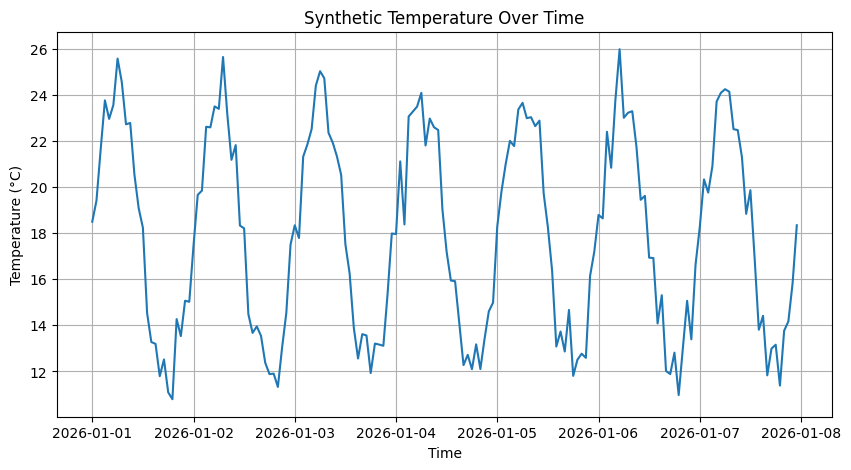

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(weather_df["timestamp"], weather_df["temperature_c"])
plt.title("Synthetic Temperature Over Time")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

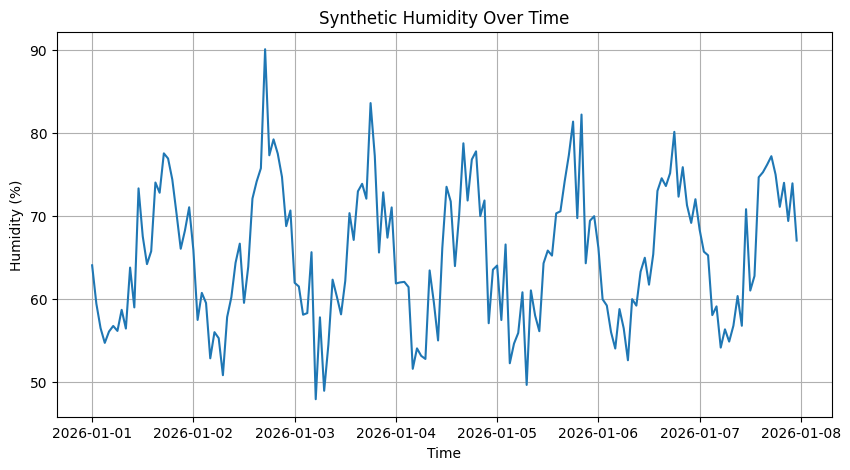

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(weather_df["timestamp"], weather_df["humidity_percent"])
plt.title("Synthetic Humidity Over Time")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.grid(True)
plt.show()

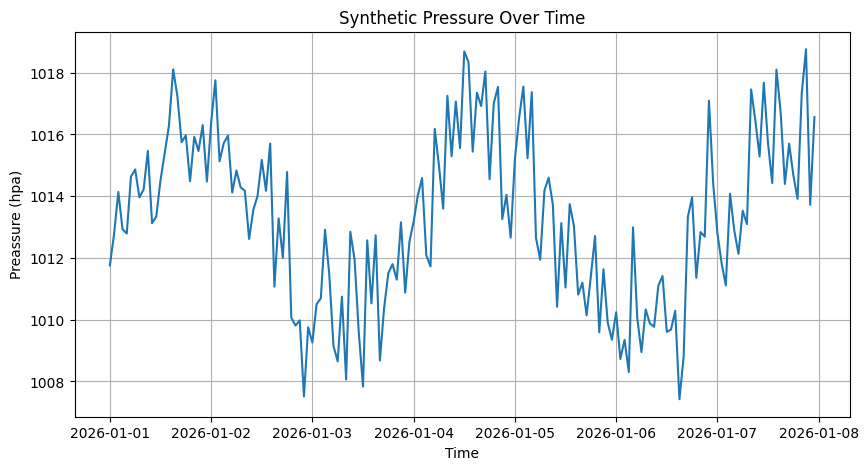

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(weather_df["timestamp"], weather_df["pressure_hpa"])
plt.title("Synthetic Pressure Over Time")
plt.xlabel("Time")
plt.ylabel("Preassure (hpa)")
plt.grid(True)
plt.show()

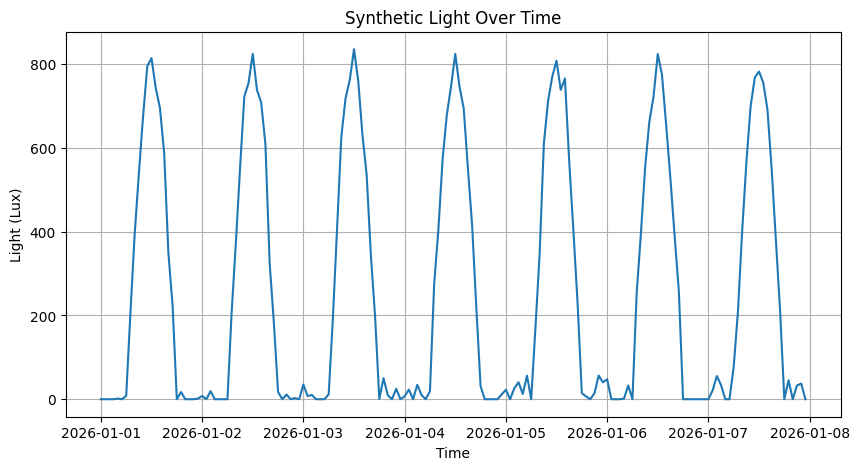

In [28]:
plt.figure(figsize=(10,5))
plt.plot(weather_df["timestamp"], weather_df["light_lux"])
plt.title("Synthetic Light Over Time")
plt.xlabel("Time")
plt.ylabel("Light (Lux)")
plt.grid(True)
plt.show()


## 12. Compare weather variables

We create a simple comparison of the main weather variables.

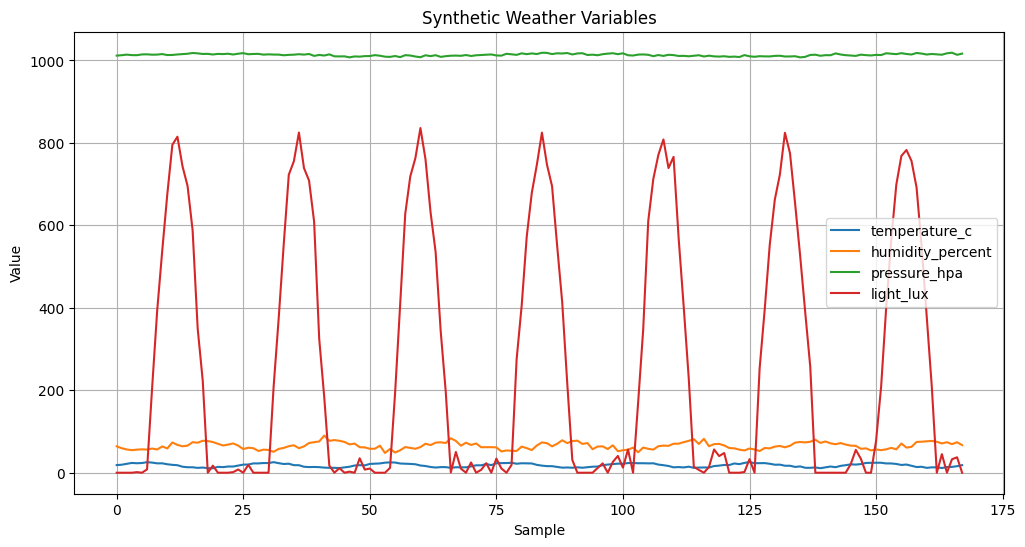

In [29]:
weather_df[["temperature_c", "humidity_percent", "pressure_hpa", "light_lux"]].plot(
    figsize=(12, 6)
)

plt.title("Synthetic Weather Variables")
plt.xlabel("Sample")
plt.ylabel("Value")
plt.grid(True)
plt.show()

## 13. Conclusions

- The synthetic dataset contains 7 days of hourly weather station data.
- Temperature follows a daily cycle, increasing during the day and decreasing at night.
- Humidity shows an inverse pattern compared to temperature.
- Pressure changes more slowly and with smaller variations.
- Light intensity is close to zero during the night and increases during daylight hours.
- This dataset can be used later to practice data cleaning, anomaly detection and Machine Learning.